In [1]:
# =====================================
# BLOCK 1 - IMPORTS
# =====================================
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

print("Imports done.")

Imports done.


In [2]:
# =====================================
# BLOCK 2 - DATASET PATHS
# =====================================
TRAIN_IMG_DIR  = r"D:\FLOOD_DETECTION_PROJECT\dataset\train_images"
TRAIN_MASK_DIR = r"D:\FLOOD_DETECTION_PROJECT\dataset\train_masks"
VAL_IMG_DIR    = r"D:\FLOOD_DETECTION_PROJECT\dataset\val_images"
VAL_MASK_DIR   = r"D:\FLOOD_DETECTION_PROJECT\dataset\val_masks"

IMG_SIZE    = 256
NUM_CLASSES = 10

print("Train images:", len(os.listdir(TRAIN_IMG_DIR)))
print("Train masks: ", len(os.listdir(TRAIN_MASK_DIR)))
print("Val images:  ", len(os.listdir(VAL_IMG_DIR)))
print("Val masks:   ", len(os.listdir(VAL_MASK_DIR)))

Train images: 315
Train masks:  320
Val images:   78
Val masks:    78


In [3]:
# =====================================
# BLOCK 3 - LOAD PAIR FUNCTION
# =====================================
def load_pair(img_name, is_val=False):
    img_dir  = VAL_IMG_DIR  if is_val else TRAIN_IMG_DIR
    mask_dir = VAL_MASK_DIR if is_val else TRAIN_MASK_DIR

    base       = os.path.splitext(img_name)[0]
    mask_fname = base + "_lab.png"

    img_path  = os.path.join(img_dir,  img_name)
    mask_path = os.path.join(mask_dir, mask_fname)

    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
    image = image / 255.0

    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)

    return image.astype(np.float32), mask.astype(np.uint8)

print("load_pair function ready.")

load_pair function ready.


In [4]:
# =====================================
# BLOCK 4 - TRAIN/VAL LISTS
# =====================================
def get_matched_pairs(img_dir, mask_dir):
    matched = []
    for fname in sorted(os.listdir(img_dir)):
        base       = os.path.splitext(fname)[0]
        mask_fname = base + "_lab.png"
        if os.path.exists(os.path.join(mask_dir, mask_fname)):
            matched.append(fname)
    return matched

train_images = get_matched_pairs(TRAIN_IMG_DIR, TRAIN_MASK_DIR)
val_images   = get_matched_pairs(VAL_IMG_DIR,   VAL_MASK_DIR)

print("Train pairs:", len(train_images))
print("Val pairs:  ", len(val_images))

Train pairs: 315
Val pairs:   78


In [5]:
# =====================================
# BLOCK 5 - LOAD DATASET (Cache-First)
# =====================================
from concurrent.futures import ThreadPoolExecutor

CACHE_DIR = r"D:\FLOOD_DETECTION_PROJECT\cache"
os.makedirs(CACHE_DIR, exist_ok=True)

NUM_WORKERS = 2
BATCH_SIZE  = 25

cache_paths = {
    "X_train": os.path.join(CACHE_DIR, "X_train.npy"),
    "Y_train": os.path.join(CACHE_DIR, "Y_train.npy"),
    "X_val":   os.path.join(CACHE_DIR, "X_val.npy"),
    "Y_val":   os.path.join(CACHE_DIR, "Y_val.npy"),
}

def load_batch(args):
    img_names, is_val = args
    results = []
    for name in img_names:
        img, mask = load_pair(name, is_val=is_val)
        results.append((img, mask))
    return results

def load_dataset_batched(image_list, is_val=False):
    all_imgs, all_masks = [], []
    total = len(image_list)
    for batch_start in range(0, total, BATCH_SIZE):
        batch  = image_list[batch_start : batch_start + BATCH_SIZE]
        mid    = len(batch) // 2
        chunks = [(batch[:mid], is_val), (batch[mid:], is_val)]
        with ThreadPoolExecutor(max_workers=NUM_WORKERS) as executor:
            futures = [executor.submit(load_batch, chunk) for chunk in chunks if chunk[0]]
            for f in futures:
                for img, mask in f.result():
                    all_imgs.append(img)
                    all_masks.append(mask)
        print(f"  Loaded {min(batch_start + BATCH_SIZE, total)}/{total}", end="\r")
    return all_imgs, all_masks

if all(os.path.exists(p) for p in cache_paths.values()):
    print("Cache found. Loading as memory-mapped arrays...")
    X_train = np.load(cache_paths["X_train"], mmap_mode="r")
    Y_train = np.load(cache_paths["Y_train"], mmap_mode="r")
    X_val   = np.load(cache_paths["X_val"],   mmap_mode="r")
    Y_val   = np.load(cache_paths["Y_val"],   mmap_mode="r")
    print("Loaded (memory-mapped).")
else:
    print("No cache found. Loading from images...")
    print("Loading train set...")
    X_train_list, Y_train_list = load_dataset_batched(train_images, is_val=False)
    print("\nLoading val set...")
    X_val_list, Y_val_list     = load_dataset_batched(val_images,   is_val=True)

    X_train = np.array(X_train_list, dtype=np.float32)
    Y_train = np.array(Y_train_list, dtype=np.uint8)
    X_val   = np.array(X_val_list,   dtype=np.float32)
    Y_val   = np.array(Y_val_list,   dtype=np.uint8)

    del X_train_list, Y_train_list, X_val_list, Y_val_list

    np.save(cache_paths["X_train"], X_train)
    np.save(cache_paths["Y_train"], Y_train)
    np.save(cache_paths["X_val"],   X_val)
    np.save(cache_paths["Y_val"],   Y_val)
    print("Saved to cache.")

print("X_train:", X_train.shape)
print("Y_train:", Y_train.shape)
print("X_val:  ", X_val.shape)
print("Y_val:  ", Y_val.shape)

Cache found. Loading as memory-mapped arrays...
Loaded (memory-mapped).
X_train: (315, 256, 256, 3)
Y_train: (315, 256, 256)
X_val:   (78, 256, 256, 3)
Y_val:   (78, 256, 256)


In [6]:
# =====================================
# BLOCK 6 - MODEL DEFINITION
# [UPDATED] Auto GPU detection
# =====================================
import segmentation_models_pytorch as smp
import torch

# Auto-detect GPU
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    print(f"GPU detected: {torch.cuda.get_device_name(0)}")
    print(f"GPU memory:   {round(torch.cuda.get_device_properties(0).total_memory / 1e9, 2)} GB")
else:
    DEVICE = torch.device("cpu")
    print("No GPU found, using CPU.")

model = smp.UnetPlusPlus(
    encoder_name    = "efficientnet-b3",
    encoder_weights = "imagenet",
    in_channels     = 3,
    classes         = 1,
    activation      = None
)

model = model.to(DEVICE)
print("Model ready on:", DEVICE)
print("Total params:", sum(p.numel() for p in model.parameters()))

c:\Users\Bidita Adhikari\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


GPU detected: NVIDIA GeForce RTX 2050
GPU memory:   4.29 GB
Model ready on: cuda
Total params: 13624793


In [7]:
# =====================================
# BLOCK 7 - DATALOADER SETUP
# [UPDATED] Correct flood classes + larger batch for GPU
# =====================================
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
import random

all_unique = set()
for i in range(min(20, len(Y_train))):
    all_unique.update(np.unique(np.array(Y_train[i])).tolist())

print("Unique mask values (sampled):", sorted(all_unique))

# FIXED: correct flood classes from class_mapping.csv
# 1=Building-flooded, 3=Road-flooded, 5=Water
FLOOD_CLASSES = {1, 3, 5}
print("Using flood classes:", FLOOD_CLASSES)

class FloodDataset(Dataset):
    def __init__(self, images, masks, augment=False):
        self.images  = images
        self.masks   = masks
        self.augment = augment

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img  = torch.tensor(np.array(self.images[idx])).permute(2, 0, 1).float()

        mask = np.array(self.masks[idx]).astype(np.uint8)
        # FIXED: combine all flood classes into binary mask
        mask = np.isin(mask, list(FLOOD_CLASSES)).astype(np.float32)
        mask = torch.tensor(mask).unsqueeze(0).float()

        if self.augment:
            if random.random() > 0.5:
                img  = TF.hflip(img)
                mask = TF.hflip(mask)
            if random.random() > 0.5:
                img  = TF.vflip(img)
                mask = TF.vflip(mask)
            if random.random() > 0.5:
                k    = random.choice([1, 2, 3])
                img  = torch.rot90(img,  k, dims=[1, 2])
                mask = torch.rot90(mask, k, dims=[1, 2])

        return img, mask

# UPDATED: larger batch + more workers for GPU
train_loader = DataLoader(FloodDataset(X_train, Y_train, augment=True),
                          batch_size=16, shuffle=True,
                          num_workers=0,       # ← change to 0 on Windows
                          pin_memory=True)

val_loader   = DataLoader(FloodDataset(X_val, Y_val, augment=False),
                          batch_size=16, shuffle=False,
                          num_workers=0,       # ← change to 0 on Windows
                          pin_memory=True)

print("Train batches:", len(train_loader), "| Val batches:", len(val_loader))

Unique mask values (sampled): [0, 2, 4, 5, 6, 7, 8, 9]
Using flood classes: {1, 3, 5}
Train batches: 20 | Val batches: 5


In [8]:
import torch

print("CUDA available:", torch.cuda.is_available())
print("Device:", DEVICE)
print("Model on GPU:", next(model.parameters()).is_cuda)

# Send a dummy tensor to GPU to confirm it works
dummy = torch.randn(1, 3, 256, 256).to(DEVICE)
out   = model(dummy)
print("Dummy forward pass output shape:", out.shape)
print("GPU memory after dummy:", round(torch.cuda.memory_allocated() / 1e9, 3), "GB")

CUDA available: True
Device: cuda
Model on GPU: True
Dummy forward pass output shape: torch.Size([1, 1, 256, 256])
GPU memory after dummy: 0.418 GB


In [9]:
# =====================================
# BLOCK 8 - TRAINING LOOP
# [UPDATED] Mixed precision for faster GPU training
# =====================================
import torch.nn as nn
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.amp import GradScaler, autocast
import time

EPOCHS   = 30
LR       = 1e-3
PATIENCE = 5

def dice_bce_loss(preds, targets, smooth=1e-6):
    preds_sig = torch.sigmoid(preds)
    inter = (preds_sig * targets).sum(dim=(2, 3))
    dice  = 1 - (2 * inter + smooth) / (
        preds_sig.sum(dim=(2, 3)) + targets.sum(dim=(2, 3)) + smooth
    )
    bce = nn.functional.binary_cross_entropy_with_logits(preds, targets)
    return dice.mean() + bce

criterion = dice_bce_loss
optimizer = Adam(model.parameters(), lr=LR)
scheduler = ReduceLROnPlateau(optimizer, mode="min", patience=3, factor=0.5)

scaler = GradScaler("cuda") if DEVICE.type == "cuda" else None

best_val_loss = float("inf")
no_improve    = 0
train_losses  = []
val_losses    = []

for epoch in range(1, EPOCHS + 1):
    start = time.time()

    model.train()
    train_loss = 0
    for imgs, masks in train_loader:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        optimizer.zero_grad()

        if scaler:
            with autocast("cuda"):          # ✅ fixed indentation
                preds = model(imgs)         # ✅ fixed indentation
                loss  = criterion(preds, masks)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            preds = model(imgs)
            loss  = criterion(preds, masks)
            loss.backward()
            optimizer.step()

        train_loss += loss.item()
    train_loss /= len(train_loader)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            if scaler:
                with autocast("cuda"):      # ✅ added "cuda"
                    preds = model(imgs)
            else:
                preds = model(imgs)
            val_loss += criterion(preds, masks).item()
    val_loss /= len(val_loader)

    scheduler.step(val_loss)
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    elapsed = time.time() - start
    if DEVICE.type == "cuda":
        mem = round(torch.cuda.memory_allocated() / 1e9, 2)
        print(f"Epoch {epoch:02d}/{EPOCHS} | Train: {train_loss:.4f} | Val: {val_loss:.4f} | Time: {elapsed:.1f}s | GPU: {mem}GB")
    else:
        print(f"Epoch {epoch:02d}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Time: {elapsed:.1f}s")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), r"D:\FLOOD_DETECTION_PROJECT\best_model.pth")
        print(f"  ✅ Best model saved (val_loss={best_val_loss:.4f})")
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f"  ⏹ Early stopping at epoch {epoch}")
            break

print("\nTraining complete. Best val loss:", round(best_val_loss, 4))

Epoch 01/30 | Train: 1.1539 | Val: 1.4357 | Time: 12.0s | GPU: 0.6GB
  ✅ Best model saved (val_loss=1.4357)
Epoch 02/30 | Train: 0.9103 | Val: 0.8978 | Time: 9.9s | GPU: 0.6GB
  ✅ Best model saved (val_loss=0.8978)
Epoch 03/30 | Train: 0.8927 | Val: 0.9621 | Time: 9.9s | GPU: 0.6GB
Epoch 04/30 | Train: 0.8610 | Val: 0.9452 | Time: 9.9s | GPU: 0.6GB
Epoch 05/30 | Train: 0.8144 | Val: 0.9574 | Time: 9.9s | GPU: 0.6GB
Epoch 06/30 | Train: 0.8020 | Val: 0.8229 | Time: 10.0s | GPU: 0.6GB
  ✅ Best model saved (val_loss=0.8229)
Epoch 07/30 | Train: 0.7920 | Val: 0.8437 | Time: 9.9s | GPU: 0.6GB
Epoch 08/30 | Train: 0.7883 | Val: 0.9098 | Time: 9.9s | GPU: 0.6GB
Epoch 09/30 | Train: 0.7957 | Val: 0.9423 | Time: 10.0s | GPU: 0.6GB
Epoch 10/30 | Train: 0.7671 | Val: 0.8167 | Time: 9.9s | GPU: 0.6GB
  ✅ Best model saved (val_loss=0.8167)
Epoch 11/30 | Train: 0.7524 | Val: 0.7802 | Time: 9.9s | GPU: 0.6GB
  ✅ Best model saved (val_loss=0.7802)
Epoch 12/30 | Train: 0.7705 | Val: 0.8242 | Time: 9.9s

In [10]:
import torch
print(torch.__version__)
print(torch.version.cuda)

2.6.0+cu124
12.4


In [11]:
# =====================================
# BLOCK 9 - EVALUATION & METRICS
# =====================================
model.load_state_dict(torch.load(r"D:\FLOOD_DETECTION_PROJECT\best_model.pth", map_location=DEVICE))
model.eval()

def compute_metrics(loader, model, threshold=0.5):
    iou_scores, dice_scores, acc_scores = [], [], []
    with torch.no_grad():
        for imgs, masks in loader:
            imgs  = imgs.to(DEVICE)
            preds = torch.sigmoid(model(imgs)).cpu().numpy()
            masks = masks.numpy()

            preds_bin = (preds > threshold).astype(np.uint8)
            masks_bin = (masks > 0.5).astype(np.uint8)

            for p, m in zip(preds_bin, masks_bin):
                inter = (p & m).sum()
                union = (p | m).sum()
                iou_scores.append(inter / (union + 1e-6))
                dice_scores.append((2 * inter) / (p.sum() + m.sum() + 1e-6))
                acc_scores.append((p == m).mean())

    return {
        "IoU":      round(float(np.mean(iou_scores))  * 100, 2),
        "Dice":     round(float(np.mean(dice_scores)) * 100, 2),
        "Accuracy": round(float(np.mean(acc_scores))  * 100, 2),
    }

print("\nEvaluating on validation set...")
val_metrics = compute_metrics(val_loader, model)
print(f"  IoU:      {val_metrics['IoU']}%")
print(f"  Dice:     {val_metrics['Dice']}%")
print(f"  Accuracy: {val_metrics['Accuracy']}%")


Evaluating on validation set...
  IoU:      37.7%
  Dice:     42.11%
  Accuracy: 95.37%


In [12]:
# =====================================
# BLOCK 10 - SAVE & EXPORT MODEL
# [UPDATED] Move to CPU for ONNX export
# =====================================
import subprocess, sys

try:
    import onnx
    print("onnx already installed, version:", onnx.__version__)
except ModuleNotFoundError:
    print("onnx not found. Installing...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "onnx"])
    import onnx
    print("onnx installed successfully.")

SAVE_DIR = r"D:\FLOOD_DETECTION_PROJECT\saved_model"
os.makedirs(SAVE_DIR, exist_ok=True)

torch.save(model.state_dict(), os.path.join(SAVE_DIR, "unetpp_flood_full.pth"))
torch.save(model.state_dict(), os.path.join(SAVE_DIR, "unetpp_flood_weights.pth"))

# Move to CPU for ONNX export
model_cpu = model.to("cpu")
model_cpu.eval()
dummy_input = torch.randn(1, 3, 256, 256)
torch.onnx.export(
    model_cpu, dummy_input,
    os.path.join(SAVE_DIR, "unetpp_flood.onnx"),
    input_names   = ["image"],
    output_names  = ["flood_mask"],
    opset_version = 11
)
model = model.to(DEVICE)  # move back to GPU

print("Saved:")
print("  Full model  →", SAVE_DIR + "\\unetpp_flood_full.pth")
print("  Weights     →", SAVE_DIR + "\\unetpp_flood_weights.pth")
print("  ONNX export →", SAVE_DIR + "\\unetpp_flood.onnx")

onnx already installed, version: 1.21.0


c:\Users\Bidita Adhikari\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\onnx\_internal\jit_utils.py:308: UserWarning: Constant folding - Only steps=1 can be constant folded for opset >= 10 onnx::Slice op. Constant folding not applied. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\jit\passes\onnx\constant_fold.cpp:180.)
  _C._jit_pass_onnx_node_shape_type_inference(node, params_dict, opset_version)
c:\Users\Bidita Adhikari\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\onnx\utils.py:657: UserWarning: Constant folding - Only steps=1 can be constant folded for opset >= 10 onnx::Slice op. Constant folding not applied. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\jit\passes\onnx\constant_fold.cpp:180.)
  _C._jit_pass_onnx_graph_shape_type_inference(
c:\Users\Bidita Adhikari\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\onnx\utils.py:1127: UserWarning: Constant fol

Saved:
  Full model  → D:\FLOOD_DETECTION_PROJECT\saved_model\unetpp_flood_full.pth
  Weights     → D:\FLOOD_DETECTION_PROJECT\saved_model\unetpp_flood_weights.pth
  ONNX export → D:\FLOOD_DETECTION_PROJECT\saved_model\unetpp_flood.onnx


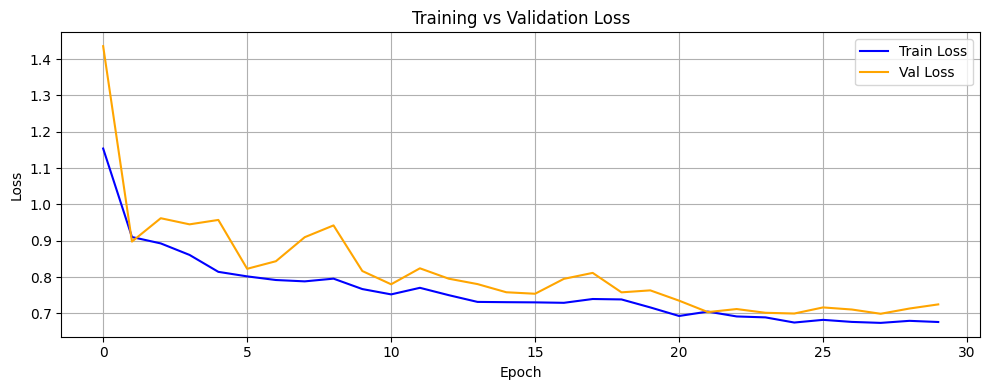

Loss curve saved.


In [13]:
# =====================================
# BLOCK 11 - TRAINING PLOTS
# =====================================
PLOT_DIR = r"D:\FLOOD_DETECTION_PROJECT\plots"
os.makedirs(PLOT_DIR, exist_ok=True)

plt.figure(figsize=(10, 4))
plt.plot(train_losses, label="Train Loss", color="blue")
plt.plot(val_losses,   label="Val Loss",   color="orange")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "loss_curve.png"))
plt.show()
print("Loss curve saved.")

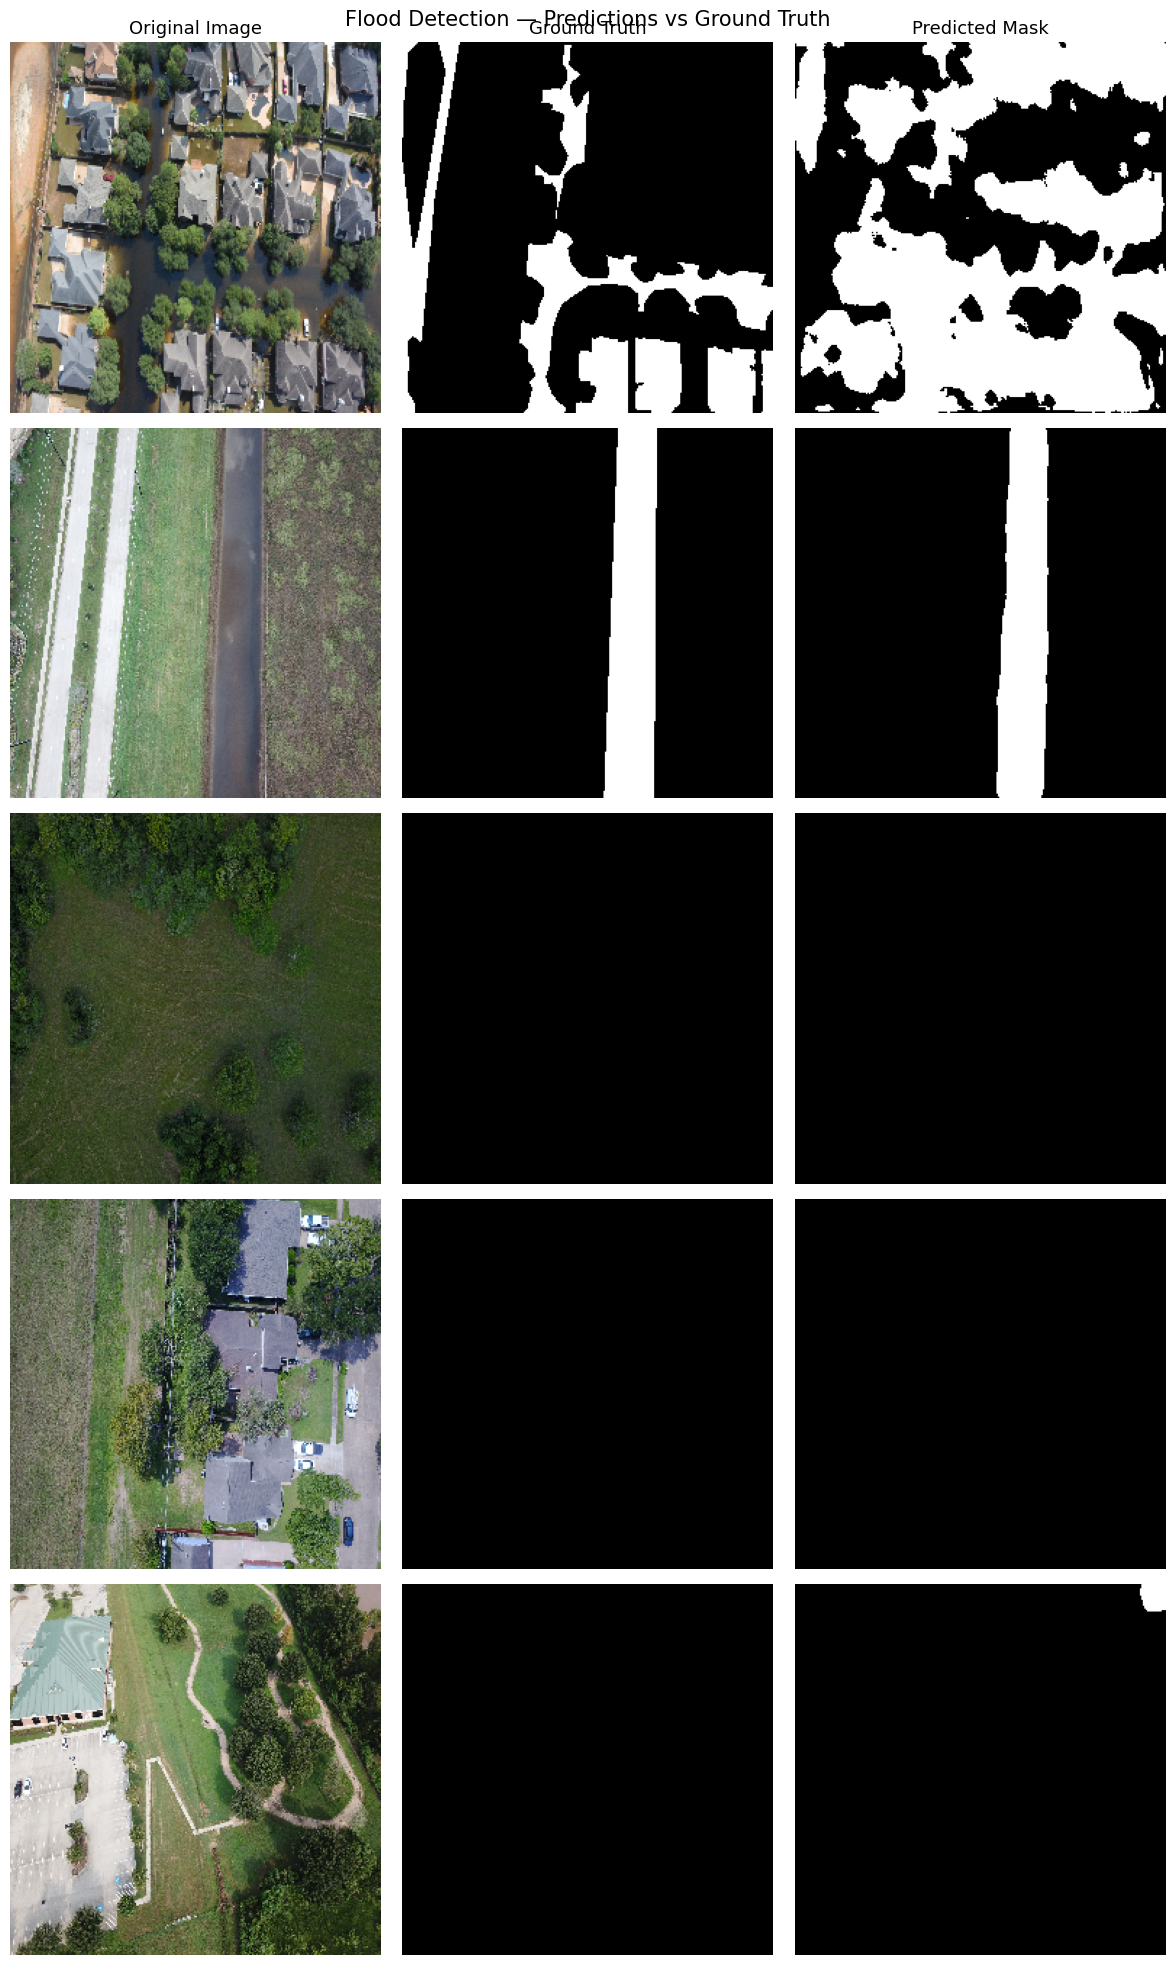

Prediction plot saved.


In [17]:
# =====================================
# BLOCK 12 - PREDICTION VISUALIZATION
# [UPDATED] Uses FLOOD_CLASSES for correct ground truth
# =====================================
indices = np.random.choice(len(X_val), 5, replace=False)

fig, axes = plt.subplots(5, 3, figsize=(12, 20))
axes[0, 0].set_title("Original Image", fontsize=13)
axes[0, 1].set_title("Ground Truth",   fontsize=13)
axes[0, 2].set_title("Predicted Mask", fontsize=13)

for row, idx in enumerate(indices):
    img  = np.array(X_val[idx])
    mask = np.array(Y_val[idx])

    # FIXED: correct flood classes for ground truth
    mask_display = np.isin(mask, list(FLOOD_CLASSES)).astype(np.float32)

    img_tensor = torch.tensor(img).permute(2, 0, 1).unsqueeze(0).float().to(DEVICE)
    with torch.no_grad():
        pred     = torch.sigmoid(model(img_tensor)).squeeze().cpu().numpy()
    pred_bin = (pred > 0.5).astype(np.float32)

    axes[row, 0].imshow(img)
    axes[row, 0].axis("off")
    axes[row, 1].imshow(mask_display, cmap="gray")
    axes[row, 1].axis("off")
    axes[row, 2].imshow(pred_bin, cmap="gray")
    axes[row, 2].axis("off")

plt.suptitle("Flood Detection — Predictions vs Ground Truth", fontsize=15)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "predictions.png"), bbox_inches="tight")
plt.show()
print("Prediction plot saved.")

In [16]:
all_unique = set()
for i in range(len(Y_train)):
    all_unique.update(np.unique(np.array(Y_train[i])).tolist())

print("ALL unique mask values:", sorted(all_unique))

ALL unique mask values: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
